In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram,plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, concurrence
import numpy as np
from IPython.display import display

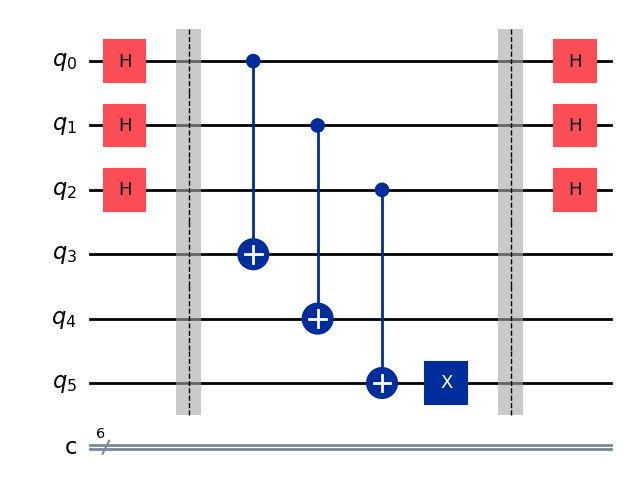

In [15]:
def quantum_oracle(circuit):
    n = circuit.num_qubits//2
    #copying x data to y

    for i in range(n):
        circuit.cx(i,i+n)
    # xor with b
    b = 0b100
    for i in range(n):
        if (b>>i)&1:
            circuit.x(i+n)
    


n = 3
sa = QuantumCircuit(2*n,2*n)
sa.h(range(n))
sa.barrier()
quantum_oracle(sa)
sa.barrier()
sa.h(range(n))
sa.draw('mpl')

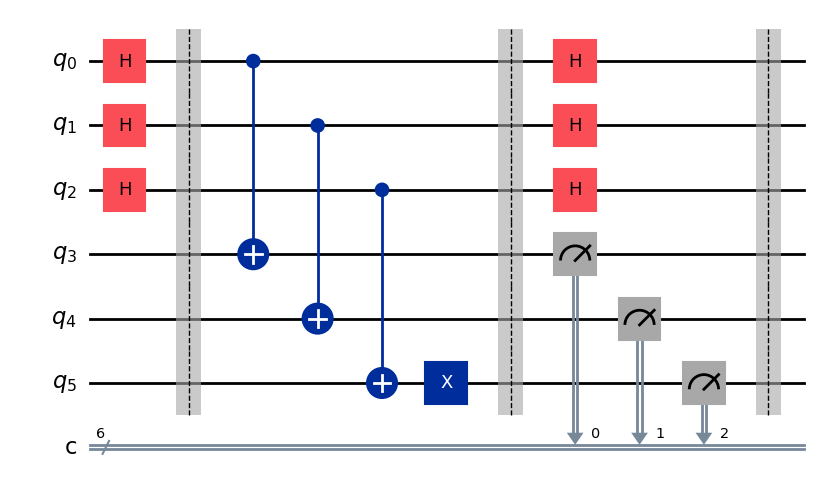

In [16]:
sa.measure([3,4,5],[0,1,2])
sa.barrier()
sa.draw('mpl')

In [17]:
aer = AerSimulator()
counts = aer.run(sa,shots=1).result().get_counts()
counts

{'000010': 1}

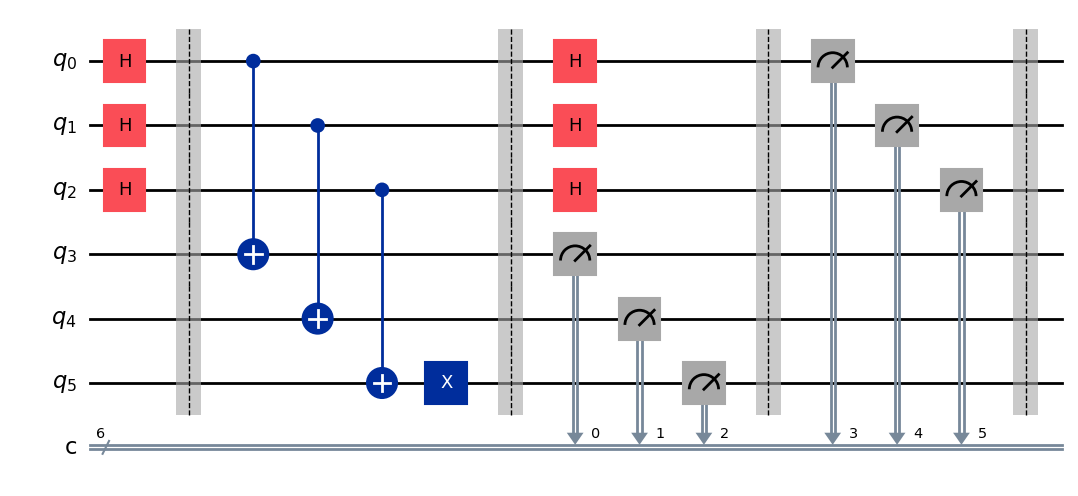

In [18]:
sa.measure([0,1,2],[3,4,5])
sa.barrier()
sa.draw('mpl')

In [19]:
aer = AerSimulator()
counts = aer.run(sa,shots=1).result().get_counts()
counts

{'000001': 1}